01. Environment Check
Python Version : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
OS             : Windows 10
PyTorch        : 2.6.0+cu124
CUDA Available : True
GPU Device     : NVIDIA GeForce RTX 4060 Ti
02. Package installation complete.

03. All libraries imported successfully.
04. Directory structure created successfully.
05. Config set — IMG_SIZE: 299×299 | Split: (0.7, 0.15, 0.15) | Seed: 42
06. Building unified file list from 3 datasets ...
    Total: 360,000 images | Real: 150,000 | Fake: 210,000
    Sources: {'DFF': 120000, '140k': 120000, 'CIFAKE': 120000}
07. Splitting dataset (70 / 15 / 15) ...
    test : 54,000 total | Real: 22,500 | Fake: 31,500
    train: 252,000 total | Real: 105,000 | Fake: 147,000
    val  : 54,000 total | Real: 22,500 | Fake: 31,500
    Saved → splits/master_split.csv
08. Track 1: Face crop preprocessing (RetinaFace) ...
    Target size: 299×299 | This may take a while ...


Track1 Face Crop: 100%|█████████████████████████████████████████████████████| 360000/360000 [27:27:32<00:00,  3.64it/s]


    Track 1 complete — Success: 100.0% (360,000 / 360,000)
    Saved → splits/track1_log.csv
09. Track 2: Full-scene preprocessing ...
    Target size: 299×299


Track2 Full Scene: 100%|██████████████████████████████████████████████████████| 360000/360000 [13:03<00:00, 459.20it/s]


    Track 2 complete — Success: 100.0% (360,000 / 360,000)
    Saved → splits/track2_log.csv
10. Generating final split CSVs ...
    train.csv → 252,000 samples (Real: 105,000 | Fake: 147,000)
    val  .csv → 54,000 samples (Real: 22,500 | Fake: 31,500)
    test .csv → 54,000 samples (Real: 22,500 | Fake: 31,500)
    Saved → splits/train.csv / val.csv / test.csv
11. Data augmentation config defined.
    AUG_RGB        : HFlip + ShiftScaleRotate + ColorJitter + GaussNoise + Compression + Normalize
    AUG_FFT        : HFlip + ShiftScaleRotate + Normalize
    AUG_FULLSCENE  : HFlip + ColorJitter + Normalize
    TRANSFORM_EVAL : Normalize only (no augmentation)
12. FFT preprocessing verification ...


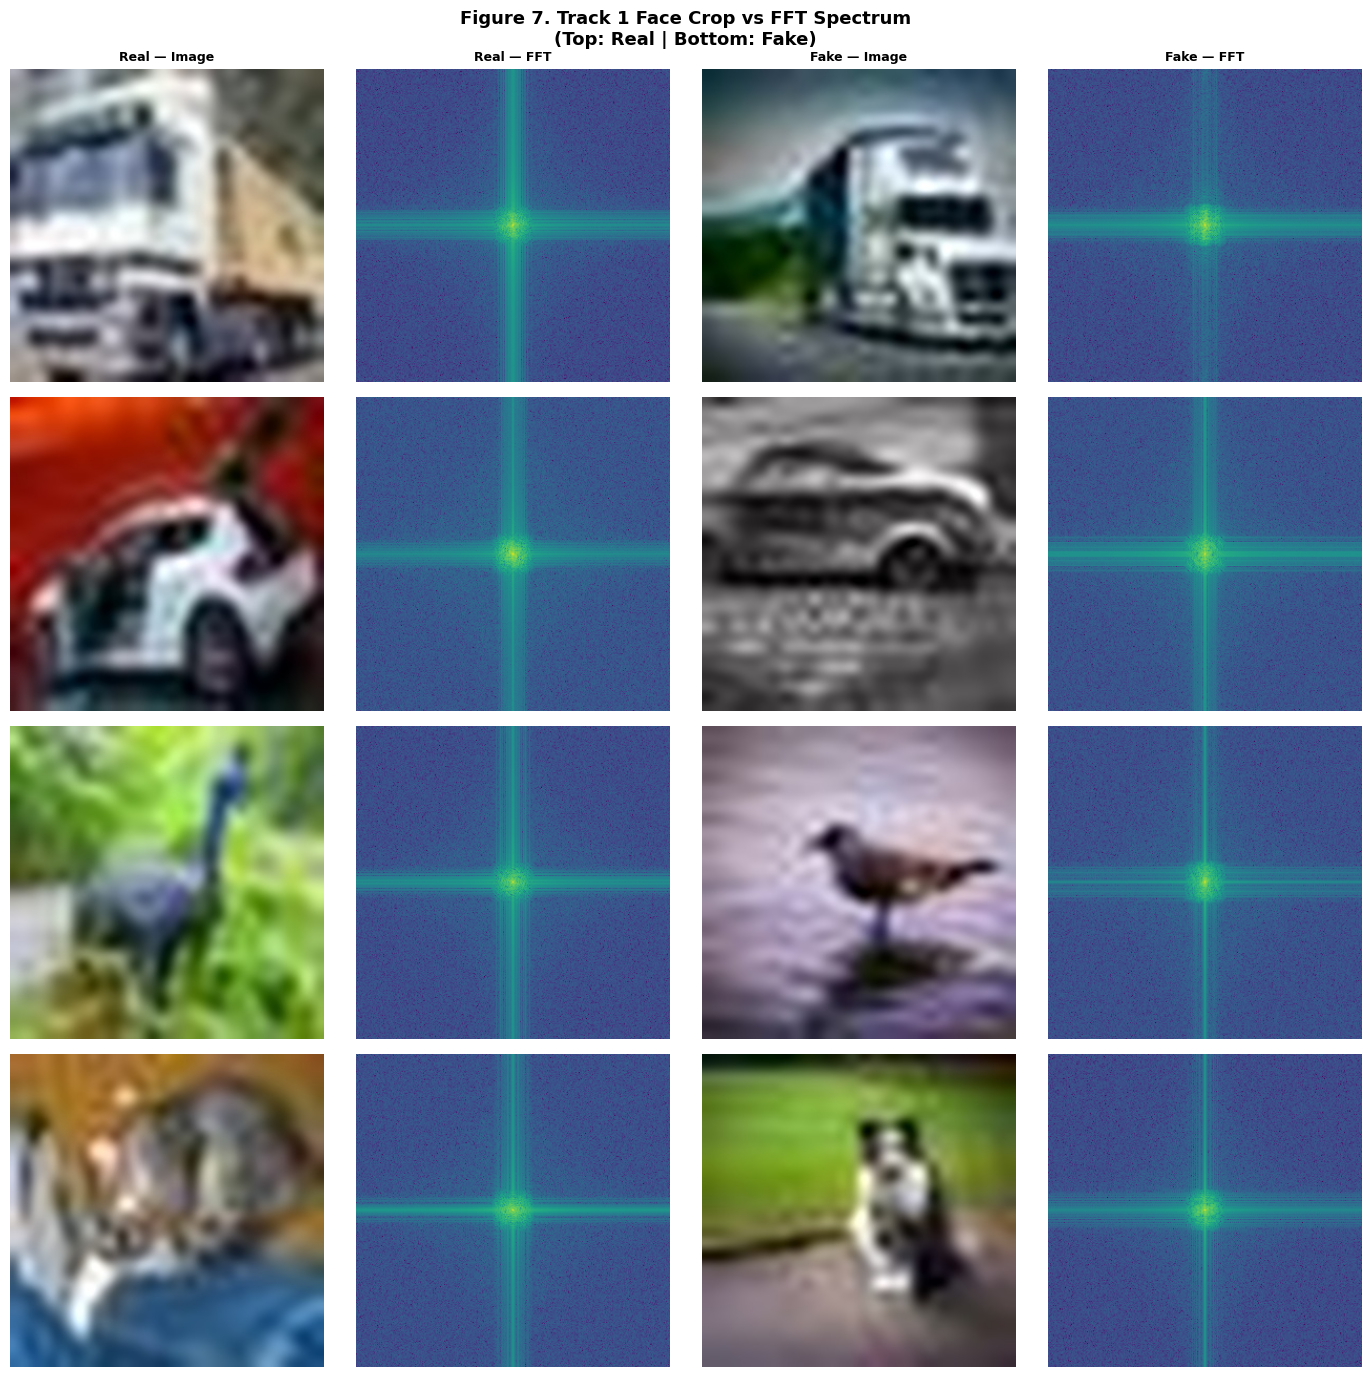

    Saved → eda_outputs/08_fft_verification.png
13. Preprocessing Summary Report
                    Subset Image Count
 Track1 — Real (face crop)     140,000
 Track1 — Fake (face crop)     150,000
Track2 — Real (full scene)     140,000
Track2 — Fake (full scene)     150,000

    train.csv : 252,000 samples
    val  .csv : 54,000 samples
    test .csv : 54,000 samples

    Saved → eda_outputs/09_preprocessing_summary.csv

ALL PREPROCESSING COMPLETE.

Notebook 02 complete. Proceed to Notebook 03: Model Training.


In [2]:
# =============================================================
# Notebook Name: 02_preprocessing.ipynb
# Project     : Multi-Stream Deepfake Detection (SFRPD-Net Extension)
# =============================================================

# ─────────────────────────────────────────
# 01. Environment Check
# ─────────────────────────────────────────
import sys
import torch
import platform

print("=" * 50)
print("01. Environment Check")
print("=" * 50)
print(f"Python Version : {sys.version}")
print(f"OS             : {platform.system()} {platform.release()}")
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device     : {torch.cuda.get_device_name(0)}")
print("=" * 50)


# ─────────────────────────────────────────
# 02. Install Required Packages
# ─────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

pip_install("opencv-python")
pip_install("retina-face")
pip_install("tf-keras")
pip_install("albumentations")
pip_install("scikit-learn")
pip_install("tqdm")
print("02. Package installation complete.")


# ─────────────────────────────────────────
# 03. Import Libraries
# ─────────────────────────────────────────
import os
import cv2
import json
import random
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from retinaface import RetinaFace

print("03. All libraries imported successfully.")


# ─────────────────────────────────────────
# 04. Directory Setup
# ─────────────────────────────────────────
BASE_DIR     = Path("./datasets")
DFF_DIR      = BASE_DIR / "DeepFakeFace"
FAKE140_DIR  = BASE_DIR / "140k_real_fake"
CIFAKE_DIR   = BASE_DIR / "CIFAKE"
FAKE140_BASE = FAKE140_DIR / "real_vs_fake" / "real-vs-fake"

# Output directories — stream-separated
PROC_DIR        = Path("./processed")
TRACK1_DIR      = PROC_DIR / "track1_face"      # RGB + FFT stream (face crop)
TRACK2_DIR      = PROC_DIR / "track2_fullscene"  # Retrieval + Physics stream (full image)
SPLIT_DIR       = PROC_DIR / "splits"            # Train / Val / Test CSV

for d in [TRACK1_DIR / "real", TRACK1_DIR / "fake",
          TRACK2_DIR / "real", TRACK2_DIR / "fake",
          SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("04. Directory structure created successfully.")


# ─────────────────────────────────────────
# 05. Configuration
# ─────────────────────────────────────────
IMG_SIZE    = 299          # Xception standard input size
VALID_EXT   = {".jpg", ".jpeg", ".png", ".webp"}
RANDOM_SEED = 42
SPLIT_RATIO = (0.70, 0.15, 0.15)   # Train / Val / Test

# ImageNet normalization stats (used in both tracks)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"05. Config set — IMG_SIZE: {IMG_SIZE}×{IMG_SIZE} | "
      f"Split: {SPLIT_RATIO} | Seed: {RANDOM_SEED}")


# ─────────────────────────────────────────
# 06. Build Unified File List (3 Datasets)
# ─────────────────────────────────────────
print("06. Building unified file list from 3 datasets ...")

def collect_files(directory: Path, label: int, source: str) -> list:
    """Collect all valid image paths with label and source tag."""
    return [
        {"path": str(f), "label": label, "source": source}
        for f in directory.rglob("*")
        if f.suffix.lower() in VALID_EXT
    ]

all_files = []

# DeepFakeFace
all_files += collect_files(DFF_DIR / "real",             label=0, source="DFF")
all_files += collect_files(DFF_DIR / "fake_inpainting",  label=1, source="DFF")
all_files += collect_files(DFF_DIR / "fake_insight",     label=1, source="DFF")
all_files += collect_files(DFF_DIR / "fake_text2img",    label=1, source="DFF")

# 140k Real and Fake Faces
all_files += collect_files(FAKE140_BASE / "train" / "real", label=0, source="140k")
all_files += collect_files(FAKE140_BASE / "train" / "fake", label=1, source="140k")
all_files += collect_files(FAKE140_BASE / "test"  / "real", label=0, source="140k")
all_files += collect_files(FAKE140_BASE / "test"  / "fake", label=1, source="140k")

# CIFAKE
all_files += collect_files(CIFAKE_DIR / "train" / "REAL", label=0, source="CIFAKE")
all_files += collect_files(CIFAKE_DIR / "train" / "FAKE", label=1, source="CIFAKE")
all_files += collect_files(CIFAKE_DIR / "test"  / "REAL", label=0, source="CIFAKE")
all_files += collect_files(CIFAKE_DIR / "test"  / "FAKE", label=1, source="CIFAKE")

df_all = pd.DataFrame(all_files)
random.seed(RANDOM_SEED)

n_real = (df_all["label"] == 0).sum()
n_fake = (df_all["label"] == 1).sum()
print(f"    Total: {len(df_all):,} images | Real: {n_real:,} | Fake: {n_fake:,}")
print(f"    Sources: {df_all['source'].value_counts().to_dict()}")


# ─────────────────────────────────────────
# 07. Train / Val / Test Split
# ─────────────────────────────────────────
print("07. Splitting dataset (70 / 15 / 15) ...")

train_ratio, val_ratio, test_ratio = SPLIT_RATIO

df_train, df_temp = train_test_split(
    df_all, test_size=(val_ratio + test_ratio),
    stratify=df_all["label"], random_state=RANDOM_SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=test_ratio / (val_ratio + test_ratio),
    stratify=df_temp["label"], random_state=RANDOM_SEED
)

df_train = df_train.copy(); df_train["split"] = "train"
df_val   = df_val.copy();   df_val["split"]   = "val"
df_test  = df_test.copy();  df_test["split"]  = "test"

df_split = pd.concat([df_train, df_val, df_test], ignore_index=True)

for split, grp in df_split.groupby("split"):
    n_r = (grp["label"] == 0).sum()
    n_f = (grp["label"] == 1).sum()
    print(f"    {split:5s}: {len(grp):,} total | Real: {n_r:,} | Fake: {n_f:,}")

df_split.to_csv(SPLIT_DIR / "master_split.csv", index=False)
print("    Saved → splits/master_split.csv")


# ─────────────────────────────────────────
# 08. Track 1 — Face Crop (RGB + FFT Stream)
# ─────────────────────────────────────────
# RetinaFace detects face bounding box.
# If no face detected → resize full image as fallback.

print("08. Track 1: Face crop preprocessing (RetinaFace) ...")
print("    Target size: 299×299 | This may take a while ...")

MARGIN = 0.2   # 20% margin around detected face bbox

def crop_face_retinaface(img_bgr: np.ndarray, margin: float = MARGIN) -> np.ndarray:
    """
    Detect face with RetinaFace and return cropped face region.
    Falls back to full image resize if no face detected.
    """
    h, w = img_bgr.shape[:2]
    try:
        faces = RetinaFace.detect_faces(img_bgr)
        if isinstance(faces, dict) and len(faces) > 0:
            # Use the first detected face
            key = list(faces.keys())[0]
            x1, y1, x2, y2 = faces[key]["facial_area"]
            # Add margin
            bw, bh = x2 - x1, y2 - y1
            x1 = max(0, int(x1 - bw * margin))
            y1 = max(0, int(y1 - bh * margin))
            x2 = min(w, int(x2 + bw * margin))
            y2 = min(h, int(y2 + bh * margin))
            return img_bgr[y1:y2, x1:x2]
    except Exception:
        pass
    return img_bgr   # fallback: full image


def preprocess_track1(src_path: str, dst_path: Path) -> bool:
    """Crop face → resize to IMG_SIZE × IMG_SIZE → save as JPEG."""
    if dst_path.exists():
        return True  # skip if already processed
    try:
        img = cv2.imread(src_path)
        if img is None:
            return False
        face = crop_face_retinaface(img)
        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE),
                          interpolation=cv2.INTER_LANCZOS4)
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(dst_path), face,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        return True
    except Exception:
        return False


track1_log = []
for _, row in tqdm(df_split.iterrows(), total=len(df_split),
                   desc="Track1 Face Crop"):
    src  = row["path"]
    cls  = "real" if row["label"] == 0 else "fake"
    stem = Path(src).stem + f"_{row['source']}"
    dst  = TRACK1_DIR / cls / f"{stem}.jpg"
    ok   = preprocess_track1(src, dst)
    track1_log.append({"src": src, "dst": str(dst),
                        "label": row["label"], "ok": ok})

df_t1 = pd.DataFrame(track1_log)
success_rate = df_t1["ok"].mean() * 100
print(f"    Track 1 complete — Success: {success_rate:.1f}% "
      f"({df_t1['ok'].sum():,} / {len(df_t1):,})")
df_t1.to_csv(SPLIT_DIR / "track1_log.csv", index=False)
print("    Saved → splits/track1_log.csv")


# ─────────────────────────────────────────
# 09. Track 2 — Full Scene (Retrieval + Physics Stream)
# ─────────────────────────────────────────
# No face crop — resize full image to IMG_SIZE × IMG_SIZE.

print("09. Track 2: Full-scene preprocessing ...")
print("    Target size: 299×299")

def preprocess_track2(src_path: str, dst_path: Path) -> bool:
    """Resize full image to IMG_SIZE × IMG_SIZE → save as JPEG."""
    if dst_path.exists():
        return True
    try:
        img = cv2.imread(src_path)
        if img is None:
            return False
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE),
                         interpolation=cv2.INTER_LANCZOS4)
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(dst_path), img,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        return True
    except Exception:
        return False


track2_log = []
for _, row in tqdm(df_split.iterrows(), total=len(df_split),
                   desc="Track2 Full Scene"):
    src  = row["path"]
    cls  = "real" if row["label"] == 0 else "fake"
    stem = Path(src).stem + f"_{row['source']}"
    dst  = TRACK2_DIR / cls / f"{stem}.jpg"
    ok   = preprocess_track2(src, dst)
    track2_log.append({"src": src, "dst": str(dst),
                        "label": row["label"], "ok": ok})

df_t2 = pd.DataFrame(track2_log)
success_rate = df_t2["ok"].mean() * 100
print(f"    Track 2 complete — Success: {success_rate:.1f}% "
      f"({df_t2['ok'].sum():,} / {len(df_t2):,})")
df_t2.to_csv(SPLIT_DIR / "track2_log.csv", index=False)
print("    Saved → splits/track2_log.csv")


# ─────────────────────────────────────────
# 10. Generate Final Split CSVs
# ─────────────────────────────────────────
print("10. Generating final split CSVs ...")

# Merge track1 dst paths into split dataframe
df_t1_map = df_t1[df_t1["ok"]][["src", "dst"]].rename(
    columns={"dst": "track1_path"})
df_t2_map = df_t2[df_t2["ok"]][["src", "dst"]].rename(
    columns={"dst": "track2_path"})

df_final = df_split.merge(df_t1_map, left_on="path", right_on="src", how="left")
df_final = df_final.merge(df_t2_map, left_on="path", right_on="src", how="left")
df_final = df_final.drop(columns=["src_x", "src_y"], errors="ignore")

for split in ["train", "val", "test"]:
    df_s = df_final[df_final["split"] == split].copy()
    df_s = df_s.dropna(subset=["track1_path", "track2_path"])
    out  = SPLIT_DIR / f"{split}.csv"
    df_s.to_csv(out, index=False)
    n_r  = (df_s["label"] == 0).sum()
    n_f  = (df_s["label"] == 1).sum()
    print(f"    {split:5s}.csv → {len(df_s):,} samples "
          f"(Real: {n_r:,} | Fake: {n_f:,})")

print("    Saved → splits/train.csv / val.csv / test.csv")


# ─────────────────────────────────────────
# 11. Data Augmentation Configuration (for Training)
# ─────────────────────────────────────────
# Applied only during training (not val/test).
# FFT track: geometric transforms only (no color jitter).

print("11. Data augmentation config defined.")

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

    # Track 1 — RGB stream augmentation
    AUG_RGB = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=10, p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2,
                      saturation=0.1, hue=0.05, p=0.4),
        A.GaussNoise(var_limit=(5, 25), p=0.3),
        A.ImageCompression(quality_lower=75, quality_upper=100, p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

    # Track 1 — FFT stream augmentation (geometry only, no color)
    AUG_FFT = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=10, p=0.5),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

    # Track 2 — Full scene augmentation
    AUG_FULLSCENE = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(brightness=0.15, contrast=0.15,
                      saturation=0.1, hue=0.05, p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

    # Validation / Test transform (no augmentation)
    TRANSFORM_EVAL = A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

    print("    AUG_RGB        : HFlip + ShiftScaleRotate + ColorJitter + "
          "GaussNoise + Compression + Normalize")
    print("    AUG_FFT        : HFlip + ShiftScaleRotate + Normalize")
    print("    AUG_FULLSCENE  : HFlip + ColorJitter + Normalize")
    print("    TRANSFORM_EVAL : Normalize only (no augmentation)")

except ImportError:
    print("    [WARNING] albumentations not installed. "
          "Augmentation config skipped.")


# ─────────────────────────────────────────
# 12. FFT Preprocessing Verification
# ─────────────────────────────────────────
# Verify FFT transform on sample images from Track 1.

print("12. FFT preprocessing verification ...")

def compute_fft(img_path: str) -> np.ndarray:
    """
    Compute log-magnitude FFT spectrum from a grayscale image.
    Returns normalized spectrum as uint8 for visualization.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    f   = np.fft.fft2(img)
    fs  = np.fft.fftshift(f)
    mag = np.log1p(np.abs(fs))
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return mag.astype(np.uint8)


# Sample 4 real and 4 fake from Track 1
sample_real = list((TRACK1_DIR / "real").glob("*.jpg"))[:4]
sample_fake = list((TRACK1_DIR / "fake").glob("*.jpg"))[:4]

if sample_real and sample_fake:
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    fig.suptitle("Figure 7. Track 1 Face Crop vs FFT Spectrum\n"
                 "(Top: Real | Bottom: Fake)",
                 fontsize=13, fontweight="bold")

    titles = ["Real — Image", "Real — FFT",
              "Fake — Image", "Fake — FFT"]
    for ax, t in zip(axes[0], titles):
        ax.set_title(t, fontsize=9, fontweight="bold")

    for i in range(4):
        r_img = cv2.cvtColor(cv2.imread(str(sample_real[i])),
                             cv2.COLOR_BGR2RGB)
        f_img = cv2.cvtColor(cv2.imread(str(sample_fake[i])),
                             cv2.COLOR_BGR2RGB)
        r_fft = compute_fft(str(sample_real[i]))
        f_fft = compute_fft(str(sample_fake[i]))

        axes[i][0].imshow(r_img);          axes[i][0].axis("off")
        axes[i][1].imshow(r_fft, cmap="viridis"); axes[i][1].axis("off")
        axes[i][2].imshow(f_img);          axes[i][2].axis("off")
        axes[i][3].imshow(f_fft, cmap="viridis"); axes[i][3].axis("off")

    plt.tight_layout()
    plt.savefig("eda_outputs/08_fft_verification.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("    Saved → eda_outputs/08_fft_verification.png")
else:
    print("    [WARNING] No processed images found in Track 1. "
          "Run steps 08–09 first.")


# ─────────────────────────────────────────
# 13. Preprocessing Summary Report
# ─────────────────────────────────────────
print("=" * 60)
print("13. Preprocessing Summary Report")
print("=" * 60)

def count_imgs(d: Path) -> int:
    if not d.exists():
        return 0
    return sum(1 for f in d.rglob("*.jpg"))

summary = {
    "Track1 — Real (face crop)"       : count_imgs(TRACK1_DIR / "real"),
    "Track1 — Fake (face crop)"       : count_imgs(TRACK1_DIR / "fake"),
    "Track2 — Real (full scene)"      : count_imgs(TRACK2_DIR / "real"),
    "Track2 — Fake (full scene)"      : count_imgs(TRACK2_DIR / "fake"),
}

df_pre_summary = pd.DataFrame(
    summary.items(), columns=["Subset", "Image Count"]
)
df_pre_summary["Image Count"] = df_pre_summary["Image Count"].apply(
    lambda x: f"{x:,}"
)
print(df_pre_summary.to_string(index=False))

# Split summary
print()
for split in ["train", "val", "test"]:
    csv = SPLIT_DIR / f"{split}.csv"
    if csv.exists():
        df_s = pd.read_csv(csv)
        print(f"    {split:5s}.csv : {len(df_s):,} samples")

df_pre_summary.to_csv("eda_outputs/09_preprocessing_summary.csv", index=False)
print("\n    Saved → eda_outputs/09_preprocessing_summary.csv")

print("\n" + "=" * 60)
print("ALL PREPROCESSING COMPLETE.")
print("=" * 60)
print("\nNotebook 02 complete. Proceed to Notebook 03: Model Training.")